# 📈 Polynomial Regression — A Complete, Visual, Math-First Guide

This notebook builds polynomial regression **from first principles**, compares it side-by-side
with linear regression, derives the math, and *animates* what happens as model complexity
(the degree) increases — including underfitting, the sweet spot, and overfitting.

**What you'll learn**

1. Simple → Multiple → Polynomial Regression (how the equations relate)
2. Why a straight line fails on curved data
3. The "trick": `PolynomialFeatures` turns a non-linear problem into a linear one
4. Full math derivation (normal equation + gradient descent)
5. Hands-on: fit degree 1, 2, 3, ..., 20, 300 and *watch* it overfit
6. Bias–Variance tradeoff, train/test error curves
7. Advantages, disadvantages, and when to actually use it
8. A quick bridge to Ridge/Lasso (how we fix overfitting)
9. **Bonus**: Using `np.polyfit` for 1D shortcuts

> 💡 Tip: Run all cells top-to-bottom (`Kernel → Restart & Run All`). Interactive sliders need
> `ipywidgets` (already imported below).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from IPython.display import HTML, Image, display

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import ipywidgets as widgets
from ipywidgets import interact

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)
print("All libraries loaded ✅")


All libraries loaded ✅


## 1. From Simple Linear → Multiple Linear → Polynomial Regression

**Simple Linear Regression** (1 feature, straight line):

$$
\hat{y} = \beta_0 + \beta_1 x
$$

**Multiple Linear Regression** (many *different* features $x_1, x_2, \dots, x_n$):

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

**Simple Polynomial Regression** (still just *one* original feature $x$, but we add its powers):

$$
\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \cdots + \beta_d x^d
$$

**Multiple Polynomial Regression** (2+ original features, with powers *and* cross-terms):

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \beta_3 x_2 + \beta_4 x_2^2 + \beta_5 x_1 x_2 + \cdots
$$

### 🔑 The key insight
Polynomial regression is **still linear regression** — just linear in the *coefficients*
$\beta_i$, not in $x$. We don't need a new algorithm; we just **engineer new features**
($x^2, x^3, \dots$) and hand them to ordinary linear regression. This is exactly what
scikit-learn's `PolynomialFeatures` does for us.

| | Linear Regression | Polynomial Regression |
|---|---|---|
| Model shape | Straight line / hyperplane | Curve |
| Equation | $\beta_0+\beta_1x$ | $\beta_0+\beta_1x+\beta_2x^2+\dots$ |
| Relationship it captures | Linear only | Non-linear (curved) |
| Still "linear model"? | Yes | Yes (linear in the $\beta$'s) |
| Risk | Underfitting on curved data | Overfitting at high degree |
| Extra hyperparameter | None | **degree** $d$ |


## 2. Create a Curved (Non-Linear) Dataset

We generate data from a **known quadratic** so we can watch models try to recover it:

$$
y = 0.8x^2 + 0.9x + 2 + \epsilon, \qquad \epsilon \sim \mathcal{N}(0,1)
$$

This mirrors the exact dataset style from the whiteboard notes (`0.8*X**2 + 0.9*X + 2 + noise`).


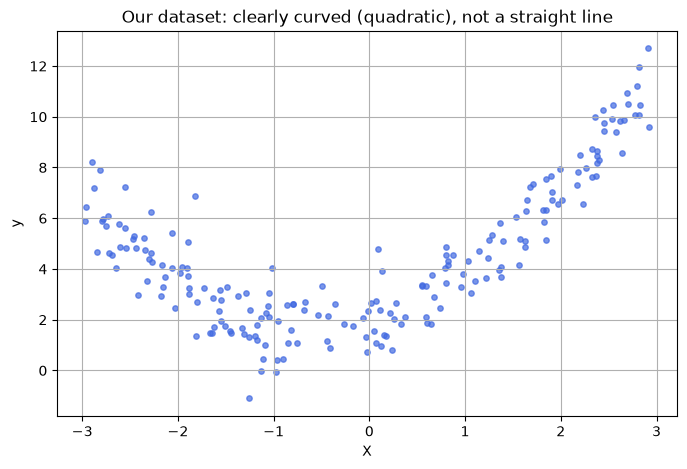

In [2]:
m = 200
X = 6 * np.random.rand(m, 1) - 3         # X in [-3, 3]
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(m, 1)

plt.scatter(X, y, color="royalblue", s=15, alpha=0.7)
plt.xlabel("X"); plt.ylabel("y")
plt.title("Our dataset: clearly curved (quadratic), not a straight line")
plt.show()


## 3. Step 1 — Try Plain Linear Regression (spoiler: it underfits)

A straight line simply *cannot* bend to follow a parabola. Let's prove it.


Linear Regression R² score: 0.3445


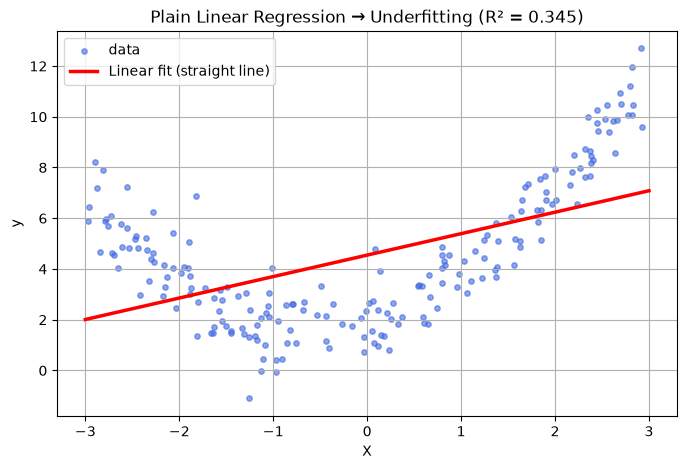

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression R² score: {r2_lr:.4f}")

X_line = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.scatter(X, y, color="royalblue", s=15, alpha=0.6, label="data")
plt.plot(X_line, lr.predict(X_line), color="red", linewidth=2.5, label="Linear fit (straight line)")
plt.xlabel("X"); plt.ylabel("y")
plt.title(f"Plain Linear Regression → Underfitting (R² = {r2_lr:.3f})")
plt.legend()
plt.show()


Notice the red line cuts straight through the curve — high **bias**, it's too simple a
model for this data. This is **underfitting**.

## 4. Step 2 — The Polynomial Feature Trick

`PolynomialFeatures(degree=d)` takes a single column $x$ and expands it into
$[1, x, x^2, \dots, x^d]$ (the `1` is the bias/intercept column). Feeding *these* columns
into ordinary `LinearRegression` lets it fit a curve, because it's now fitting a
straight line in a higher-dimensional feature space.

$$
x \;\longrightarrow\; \big[\,1,\; x,\; x^2\,\big] \quad \text{(degree = 2)}
$$

Example from the notes: a single value like $x=1.4$ becomes $[1,\ 1.4,\ 1.96]$.


In [4]:
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2  = poly2.transform(X_test)

print("Original X_train[0]      :", X_train[0])
print("Transformed X_train[0]   :", X_train_poly2[0], " -> [1, x, x^2]")

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = lr_poly2.predict(X_test_poly2)

r2_poly2 = r2_score(y_test, y_pred_poly2)
print(f"\nPolynomial (degree=2) Regression R² score: {r2_poly2:.4f}")
print(f"Improvement over plain linear regression : {r2_poly2 - r2_lr:+.4f}")


Original X_train[0]      : [1.21811375]
Transformed X_train[0]   : [1.         1.21811375 1.48380112]  -> [1, x, x^2]

Polynomial (degree=2) Regression R² score: 0.8414
Improvement over plain linear regression : +0.4969


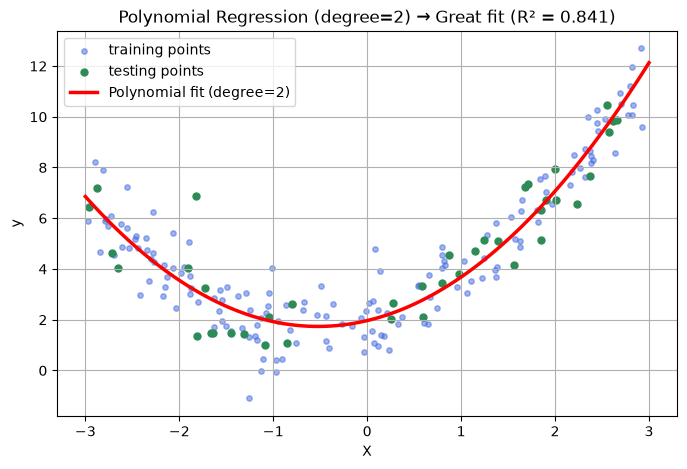

In [5]:
X_line_poly2 = poly2.transform(X_line)
plt.scatter(X_train, y_train, color="royalblue", s=15, alpha=0.5, label="training points")
plt.scatter(X_test, y_test, color="seagreen", s=25, label="testing points")
plt.plot(X_line, lr_poly2.predict(X_line_poly2), color="red", linewidth=2.5, label="Polynomial fit (degree=2)")
plt.xlabel("X"); plt.ylabel("y")
plt.title(f"Polynomial Regression (degree=2) → Great fit (R² = {r2_poly2:.3f})")
plt.legend()
plt.show()


## 5. Full Math Derivation

### 5.1 Setting up as a linear problem
For simple polynomial regression of degree $d$, define the feature vector for one sample as

$$
\boldsymbol{\phi}(x) = \begin{bmatrix}1 \\ x \\ x^2 \\ \vdots \\ x^d\end{bmatrix}, \qquad
\hat{y} = \boldsymbol{\beta}^{T}\boldsymbol{\phi}(x) = \sum_{j=0}^{d}\beta_j x^{j}
$$

Stack all $n$ samples into a **design matrix** $\Phi \in \mathbb{R}^{n\times(d+1)}$:

$$
\Phi = \begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^d
\end{bmatrix}
$$

### 5.2 Loss function (sum of squared errors)

$$
L(\boldsymbol{\beta}) = \sum_{i=1}^{n}\big(y_i - \hat{y}_i\big)^2 = \|\mathbf{y} - \Phi\boldsymbol{\beta}\|_2^2
$$

### 5.3 Closed-form solution (Normal Equation)
Minimize $L$ by setting $\nabla_{\boldsymbol{\beta}} L = 0$:

$$
\nabla_{\boldsymbol{\beta}}\|\mathbf{y}-\Phi\boldsymbol{\beta}\|^2 = -2\Phi^T(\mathbf{y}-\Phi\boldsymbol{\beta}) = 0
\;\;\Longrightarrow\;\;
\boxed{\boldsymbol{\beta} = (\Phi^T\Phi)^{-1}\Phi^T\mathbf{y}}
$$

This is **identical** to the normal equation used for ordinary linear regression — the only
difference is that $\Phi$ now contains polynomial columns instead of raw features. This is why
scikit-learn doesn't need a separate `PolynomialRegression` class: `PolynomialFeatures` +
`LinearRegression` *is* polynomial regression.

### 5.4 Gradient Descent alternative
When $n$ or $d$ is large, the matrix inverse above is expensive, so we instead update
iteratively:

$$
\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} - \eta \, \nabla_{\boldsymbol{\beta}} L(\boldsymbol{\beta})
= \boldsymbol{\beta} - \eta \cdot \big(-2\Phi^T(\mathbf{y}-\Phi\boldsymbol{\beta})\big)
$$

where $\eta$ is the learning rate. `sklearn.linear_model.SGDRegressor` uses this approach.

### 5.5 Choosing the degree — no closed-form answer
There is **no formula** that tells you the "correct" degree $d$ up front — it's a
**hyperparameter** you tune (e.g. with cross-validation), because:
- too low $d$ → can't capture the curve → **underfitting**
- too high $d$ → fits noise itself → **overfitting**


## 6. The Degree Sweep — Watch Underfitting Become Overfitting

Let's fit degrees $1, 2, 3, 6, 15, 50$ on the *same* data and look at every curve at once.


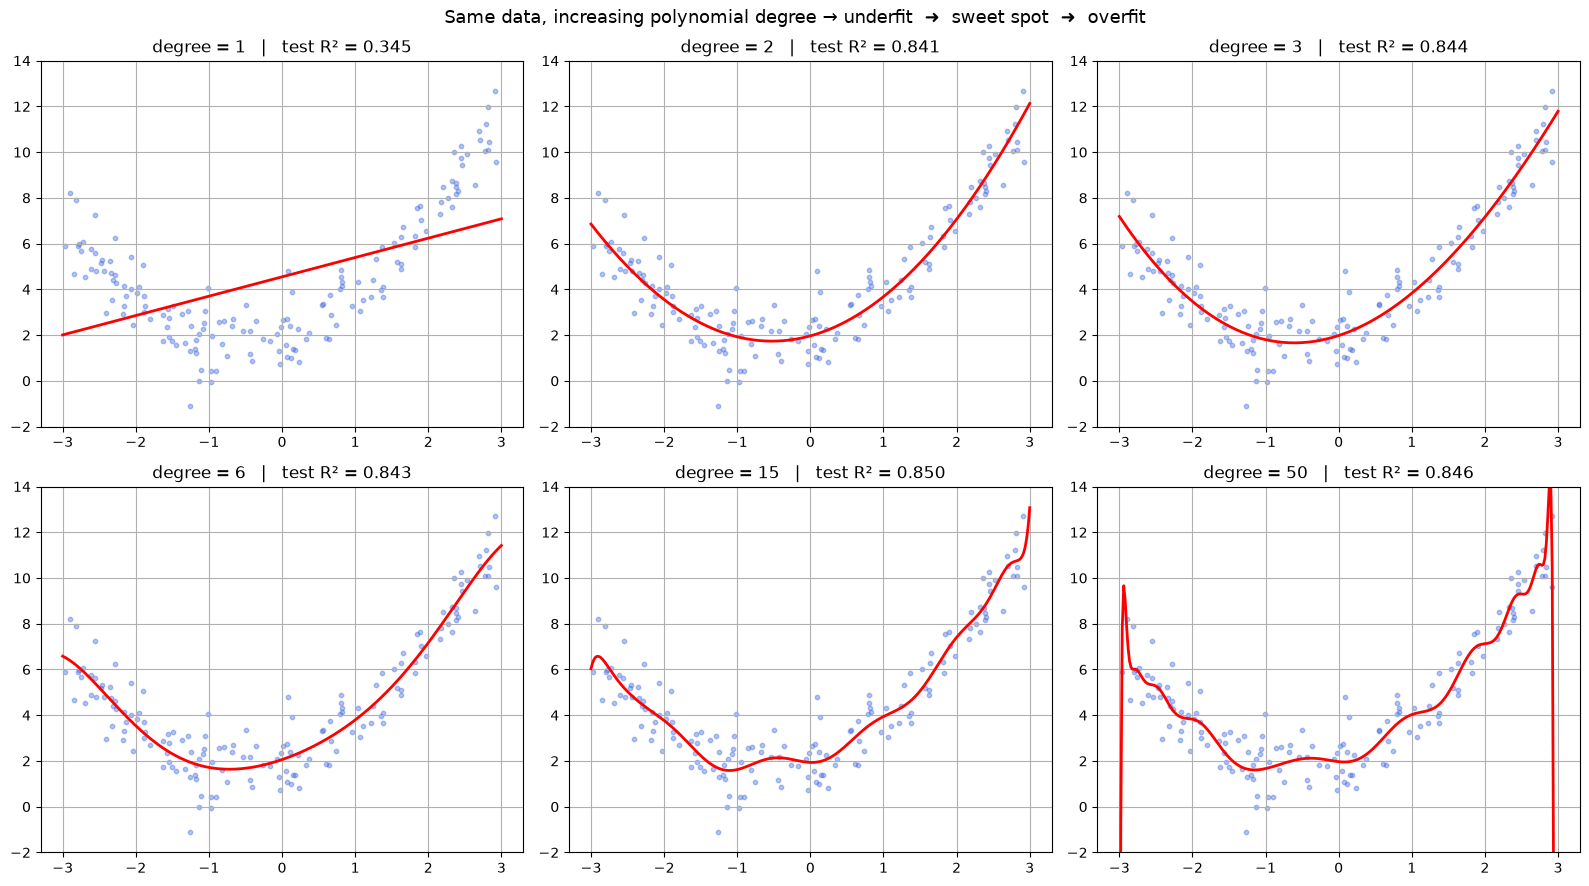

In [6]:
degrees_to_show = [1, 2, 3, 6, 15, 50]
X_line = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, d in zip(axes, degrees_to_show):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scale", StandardScaler()),
        ("lr", LinearRegression())
    ])
    pipe.fit(X_train, y_train.ravel())
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    ax.scatter(X_train, y_train, s=10, alpha=0.4, color="royalblue")
    ax.plot(X_line, pipe.predict(X_line), color="red", linewidth=2)
    ax.set_ylim(-2, 14)
    ax.set_title(f"degree = {d}   |   test R² = {r2:.3f}")

fig.suptitle("Same data, increasing polynomial degree → underfit  ➜  sweet spot  ➜  overfit",
             fontsize=13)
plt.tight_layout()
plt.show()


## 7. 🎬 Animation — Fitting Curve as Degree Increases (0 → 25)

This is the single best way to *see* the bias–variance tradeoff happen in real time.


In [7]:
degrees_anim = list(range(1, 26))
X_line = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7, 5))
scat = ax.scatter(X_train, y_train, s=15, alpha=0.5, color="royalblue", label="training data")
line, = ax.plot([], [], color="red", linewidth=2.5, label="model fit")
title = ax.set_title("")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3, 16)
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend(loc="upper center")

def update(frame):
    d = degrees_anim[frame]
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scale", StandardScaler()),
        ("lr", LinearRegression())
    ])
    pipe.fit(X_train, y_train.ravel())
    y_line = pipe.predict(X_line)
    y_line = np.clip(y_line, -3, 16)          # keep exploding curves on-screen
    line.set_data(X_line.ravel(), y_line)

    r2_train = r2_score(y_train, pipe.predict(X_train))
    r2_test  = r2_score(y_test,  pipe.predict(X_test))
    tag = "underfitting" if d <= 1 else ("overfitting" if d >= 15 else "good fit")
    title.set_text(f"degree = {d:2d}   |   train R² = {r2_train:.3f}   test R² = {r2_test:.3f}   ({tag})")
    return line, title

anim = animation.FuncAnimation(fig, update, frames=len(degrees_anim), interval=500, blit=False)
anim.save("poly_regression_animation.gif", writer=PillowWriter(fps=2))
plt.close(fig)
print("Saved animation ✅")


Saved animation ✅


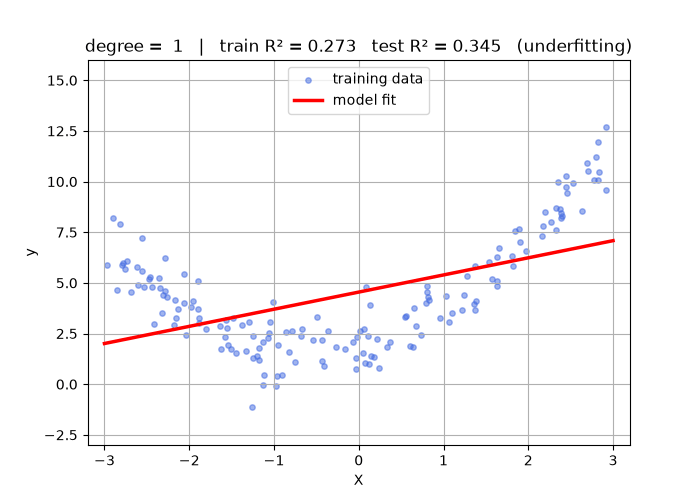

In [8]:
Image(filename="poly_regression_animation.gif")


## 8. 🎚️ Interactive Slider (drag the degree yourself)

If you're running this notebook live (not just viewing a static export), drag the slider
below to see the fit update instantly.


In [9]:
def plot_degree(degree=2):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scale", StandardScaler()),
        ("lr", LinearRegression())
    ])
    pipe.fit(X_train, y_train.ravel())
    y_line = np.clip(pipe.predict(X_line), -3, 16)

    r2_train = r2_score(y_train, pipe.predict(X_train))
    r2_test  = r2_score(y_test,  pipe.predict(X_test))

    plt.figure(figsize=(7, 5))
    plt.scatter(X_train, y_train, s=15, alpha=0.5, color="royalblue", label="train")
    plt.scatter(X_test, y_test, s=20, alpha=0.8, color="seagreen", label="test")
    plt.plot(X_line, y_line, color="red", linewidth=2.5, label=f"degree {degree} fit")
    plt.ylim(-3, 16)
    plt.title(f"degree={degree}  |  train R²={r2_train:.3f}  test R²={r2_test:.3f}")
    plt.legend()
    plt.show()

interact(plot_degree, degree=widgets.IntSlider(min=1, max=40, step=1, value=2));


interactive(children=(IntSlider(value=2, description='degree', max=40, min=1), Output()), _dom_classes=('widge…

## 9. Bias–Variance Tradeoff & the Train/Test Error Curve

$$
\text{Expected Error} = \underbrace{\text{Bias}^2}_{\text{model too simple}} +
\underbrace{\text{Variance}}_{\text{model too sensitive to noise}} + \underbrace{\sigma^2}_{\text{irreducible noise}}
$$

| Model | Bias | Variance | Regime |
|---|---|---|---|
| Linear Regression on curved data | High | Low | **Underfitting** |
| Polynomial degree ≈ 2–3 (matches truth) | Low | Low | **Just right** ✅ |
| Polynomial degree ≫ true degree (e.g. 50+) | Low | High | **Overfitting** |

The classic diagnostic: plot error vs. degree for **both** train and test sets.


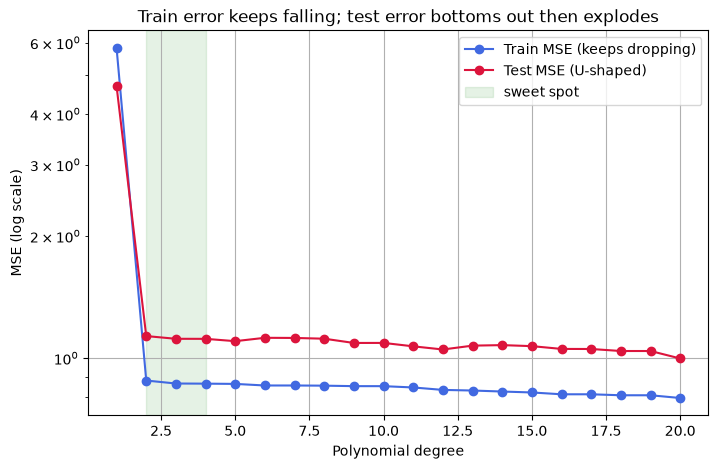

In [10]:
degree_range = range(1, 21)
train_errors, test_errors = [], []

for d in degree_range:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scale", StandardScaler()),
        ("lr", LinearRegression())
    ])
    pipe.fit(X_train, y_train.ravel())
    train_errors.append(mean_squared_error(y_train, pipe.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, pipe.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(degree_range), train_errors, "o-", label="Train MSE (keeps dropping)", color="royalblue")
plt.plot(list(degree_range), test_errors, "o-", label="Test MSE (U-shaped)", color="crimson")
plt.axvspan(2, 4, color="green", alpha=0.1, label="sweet spot")
plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("Train error keeps falling; test error bottoms out then explodes")
plt.legend()
plt.show()


- **Train error** almost always keeps decreasing as degree increases (more flexibility = can
  memorize training points).
- **Test error** decreases at first (bias drops), hits a minimum around the *true* underlying
  degree, then shoots back up (variance explodes) — the textbook **U-shaped curve**.
- The best degree is wherever **test error is lowest**, not train error.


## 10. Multiple Polynomial Regression (2 input features)

With two raw features $x_1, x_2$, `PolynomialFeatures(degree=2)` generates *all* combinations
up to degree 2:

$$
[\,1,\; x_1,\; x_2,\; x_1^2,\; x_1x_2,\; x_2^2\,]
$$

so the fitted model looks like:

$$
\hat{y} = \beta_0+\beta_1x_1+\beta_2x_2+\beta_3x_1^2+\beta_4x_1x_2+\beta_5x_2^2
$$

This produces a **curved surface** instead of a curved line — shown below in 3D.


Input features : 2
Output features: 6 -> ['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


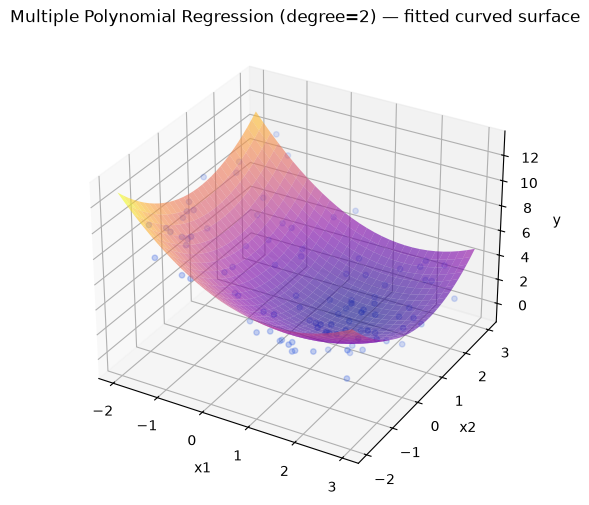

In [13]:
m2 = 100
x1 = 5 * np.random.rand(m2, 1) - 2
x2 = 5 * np.random.rand(m2, 1) - 2
y_multi = 0.7*x1**2 - 2*x1 + 3 + 0.5*x2**2 - x2 + np.random.randn(m2, 1)*1.2
X_multi = np.hstack([x1, x2])

poly_m = PolynomialFeatures(degree=2)
X_multi_poly = poly_m.fit_transform(X_multi)

print("Input features :", poly_m.n_features_in_)
print("Output features:", X_multi_poly.shape[1], "->", poly_m.get_feature_names_out(["x1", "x2"]))

lr_multi = LinearRegression().fit(X_multi_poly, y_multi.ravel())

xx1, xx2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)

grid = np.column_stack([xx1.ravel(), xx2.ravel()])
zz = lr_multi.predict(poly_m.transform(grid)).reshape(xx1.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(x1, x2, y_multi, color="royalblue", s=15, alpha=0.6)
ax.plot_surface(xx1, xx2, zz, cmap="plasma", alpha=0.6)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Multiple Polynomial Regression (degree=2) — fitted curved surface")
plt.show()

## 10.5 Bonus: The NumPy Shortcut for 1D Data (`np.polyfit`)

If you are only working with a **single input feature** (1D data) and don't need the full scikit-learn pipeline (like `StandardScaler` or cross-validation integrations), NumPy has a very convenient built-in function: `np.polyfit` and `np.poly1d`.

It fits a polynomial of a specified degree using least squares and returns the coefficients directly.


In [ ]:
# Fit a degree 3 polynomial using numpy
coeffs = np.polyfit(X_train.flatten(), y_train.flatten(), 3)
poly_func = np.poly1d(coeffs)

# Generate points for plotting
y_line_np = poly_func(X_line.flatten())

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, s=15, alpha=0.5, color="royalblue", label="train data")
plt.plot(X_line, y_line_np, color="darkorange", linewidth=3, label=f"np.polyfit (degree 3)\nEq: {poly_func}")
plt.title("Using NumPy's polyfit for quick 1D Polynomial Regression")
plt.xlabel("X"); plt.ylabel("y")
plt.legend()
plt.show()

print("Fitted Coefficients (highest degree first):")
print(coeffs)


## 11. Where Polynomial Regression Wins — and Where It Doesn't

### ✅ Advantages
- Captures **curved / non-linear** relationships while still using the fast, well-understood
  machinery of linear regression (normal equation, easy interpretability of coefficients).
- No new algorithm to learn — just a **feature transformation** (`PolynomialFeatures`) bolted
  onto ordinary linear regression.
- Works well when you already suspect (from a scatter plot or domain knowledge) a low-degree
  polynomial relationship — growth curves, projectile motion, dose–response curves, trends
  with one clear inflection, etc.
- Degree gives you a simple, single "complexity knob."

### ❌ Disadvantages
- **Extremely sensitive to degree choice** — too low underfits, too high overfits badly
  (and can blow up numerically near the edges of the data, as seen at degree 300 above).
- **Extrapolation is dangerous**: polynomials shoot off to $\pm\infty$ outside the training
  range — a degree-10 model can look great inside your data and be nonsensical one step
  outside it.
- **Feature explosion** with multiple inputs: for $p$ features and degree $d$, the number of
  polynomial terms grows combinatorially ($\binom{p+d}{d}$), which quickly becomes expensive
  and multicollinear.
- Still a **global** model — one polynomial has to fit the *entire* range of $x$, so a curve
  that changes shape locally (e.g., different slopes in different regions) needs a very high
  degree, worsening overfitting risk. (Splines / trees / kernel methods handle this better.)
- Coefficients of high-degree terms are hard to interpret physically.

### 🧭 When to reach for it
| Situation | Recommendation |
|---|---|
| Scatter plot shows a clear, smooth curve (parabola, cubic bend) | ✅ Great fit |
| Relationship might be locally jagged / has plateaus | ❌ Consider splines, decision trees, GAMs |
| You need to predict outside the observed X range | ⚠️ Be very careful, or avoid |
| You have many features and no clear low-degree structure | ❌ Consider tree ensembles / kernel methods |
| You want an interpretable, closed-form equation | ✅ Polynomial regression is one of the few non-linear models that stays interpretable |


## 12. Fixing Overfitting: A Quick Bridge to Ridge Regression (L2)

The notes show the natural next step once you've seen overfitting: **regularization**.
Ridge adds a penalty on the size of the coefficients to the same squared-error loss:

$$
L_{\text{ridge}}(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2 \;+\; \lambda\sum_{j=1}^{d}\beta_j^2
$$

- $\lambda$ (a.k.a. `alpha` in scikit-learn) is a hyperparameter, $\lambda \in [0, \infty)$.
- $\lambda = 0$ → identical to plain linear/polynomial regression.
- $\lambda \to \infty$ → coefficients shrink toward 0 → the fit flattens toward a horizontal
  line (severe underfitting).
- The right $\lambda$ shrinks the *wiggly* high-degree coefficients just enough to tame
  overfitting without losing the real curve — exactly the "before vs. after" comparison drawn
  in the notes (`y = 1.5x + 0.8` overfit line vs. `y = 0.9x + 1.5` regularized line).

Closed form (matches the derivation in the notes, generalized to matrix form):

$$
\boldsymbol{\beta}_{\text{ridge}} = (\Phi^T\Phi + \lambda I)^{-1}\Phi^T\mathbf{y}
$$


In [ ]:
alphas = [0, 1, 20, 200]
X_line = np.linspace(-3, 3, 200).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=12, alpha=0.35, color="gray", label="training data")

for alpha in alphas:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=15)),
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train.ravel())
    label = "alpha=0 (plain poly, overfitting)" if alpha == 0 else f"alpha={alpha}"
    plt.plot(X_line, np.clip(pipe.predict(X_line), -3, 16), linewidth=2, label=label)

plt.ylim(-3, 16)
plt.title("Degree-15 polynomial, increasing Ridge alpha → overfitting tamed")
plt.legend()
plt.show()


## 13. Summary Cheat-Sheet

| Concept | One-line takeaway |
|---|---|
| Polynomial regression | Linear regression on engineered features $x, x^2, \dots, x^d$ |
| Normal equation | $\boldsymbol{\beta}=(\Phi^T\Phi)^{-1}\Phi^T\mathbf{y}$ |
| Degree too low | Underfitting — high bias |
| Degree too high | Overfitting — high variance, unstable predictions |
| How to pick degree | Cross-validation; watch test error, not train error |
| Fix for overfitting | Regularization (Ridge/Lasso/Elastic Net), lower degree, more data |
| Best use case | Smooth, globally curved relationships with 1–3 features |
| Avoid when | Local/jagged patterns, need extrapolation, many features |

**Next notebook to try:** Ridge / Lasso / Elastic Net regularization in depth (L1 vs L2,
why Lasso zeroes out coefficients, and cross-validated alpha selection).
